### ⚠️ EDA Issues & Required Corrections

- **Do NOT drop `ASSESSMENT_ID`**
  - `ASSESSMENT_ID` is the **primary key required for Kaggle submission**.
  - Even if it is not used as a modeling feature, it must be preserved to:
    - correctly align predictions with test data
    - ensure submission formatting is valid
  - ✅ Fix: Keep the column in the dataset and exclude it only during feature selection (e.g., `X = df.drop(columns=[..., "ASSESSMENT_ID"])`).

---

- **Do NOT drop schools absent from training data**
  - Schools that do not appear in the training set may still appear in the **test set**.
  - Dropping them during EDA can:
    - break future merges
    - cause missing predictions at submission time
  - ✅ Fix: Retain all schools in `SCHOOLS_INFO`; rely on train/test splits rather than filtering entities manually.

---

- **Frequency encoding applied globally (potential leakage in later stages)**
  - Frequency encoding using:
    ```python
    df["school_freq"] = df["SCHOOL"].map(df["SCHOOL"].value_counts())
    ```
    is acceptable during EDA, but becomes problematic if:
    - computed before a train/validation split
    - reused directly in modeling
  - This can leak information across validation folds.
  - ✅ Fix:
    - Recompute frequency encodings **inside the training fold only**
    - Apply mapping to validation/test with `.map()` and handle unseen values (e.g., fill with 0)

---

- **Dropping `SCHOOL` and `DISTRICT` too early**
  - These columns are:
    - required for merging with test data
    - critical for feature engineering (e.g., group-level statistics)
  - Removing them during EDA prevents:
    - hierarchical feature creation
    - group-aware validation strategies
  - ✅ Fix:
    - Retain these columns through feature engineering
    - Drop only at the final modeling stage if necessary

---

- **Missing data handling may discard useful signal**
  - Columns with high missingness were dropped solely based on percentage.
  - However, missingness itself may be **informative** (not missing at random).
  - Dropping without testing removes potential predictive signal.
  - ✅ Fix:
    - For important variables, consider adding **missingness indicator features**
      ```python
      df["feature_missing"] = df["FEATURE"].isna().astype(int)
      ```
    - Then evaluate whether to keep or drop the original column

---

- **(Clarification, not an error) Target encoding**
  - Decision to avoid target encoding due to leakage risk is **valid**.
  - However, note:
    - Target encoding can be used safely with **proper cross-validation (out-of-fold encoding)**
  - ✅ Current status: No correction required, but may be revisited later if performance plateaus

---

- **EDA coverage of target variable**
  - Histograms and subgroup boxplots are present and appropriate.
  - No correction needed here.

---

### ✅ Summary

The key corrections are structural rather than analytical:
- Preserve identifiers and grouping variables
- Avoid premature column removal
- Ensure all encodings are **train-only to prevent leakage**
- Treat missingness as potential signal rather than purely noise

---

### ⚠️ Feature Engineering & Test Set Alignment (Critical Next Step)

- **Feature space must be consistent between train and test**
  - The model requires **identical columns and transformations** in both datasets.
  - Any feature created during training must also exist in the test set.
  - Failure to align feature space will result in:
    - model errors
    - incorrect or unusable predictions

---

- **Do NOT merge engineered training features directly into the test set**
  - It is incorrect to transfer features via joins such as:
    ```python
    test_df = test_df.merge(train_features, on=...)
    ```
  - This can cause:
    - data leakage
    - row mismatches
    - invalid predictions
  - ✅ Fix: Recompute or map features using transformations derived from training data only

---

- **All feature engineering must be “fit on train, applied to test”**
  - Any transformation that learns from data must use **training data only**, including:
    - frequency encoding
    - group means / aggregations
    - scaling / normalization
    - imputation values
  - ✅ Correct pattern:
    ```python
    school_freq = train_df["SCHOOL"].value_counts()

    train_df["school_freq"] = train_df["SCHOOL"].map(school_freq)
    test_df["school_freq"]  = test_df["SCHOOL"].map(school_freq).fillna(0)
    ```

---

- **Merging external datasets must be done consistently on BOTH train and test**
  - External tables (e.g., school or district data) should be merged into:
    - training set
    - test set
  - ✅ Correct:
    ```python
    train_df = train_df.merge(schools, on="SCHOOL", how="left")
    test_df  = test_df.merge(schools, on="SCHOOL", how="left")
    ```

---

- **Aggregation features must be computed from training data only**
  - Group-based features (e.g., school averages) are powerful but risky if misused
  - ❌ Incorrect:
    ```python
    df.groupby("SCHOOL")["PERCENT_PROFICIENT"].mean()
    ```
  - ✅ Correct:
    ```python
    school_mean = train_df.groupby("SCHOOL")["PERCENT_PROFICIENT"].mean()

    train_df["school_mean"] = train_df["SCHOOL"].map(school_mean)
    test_df["school_mean"]  = test_df["SCHOOL"].map(school_mean)
    ```

---

### ✅ Key Rule

> Fit all transformations on training data, then apply them to the test set. Never use test data to inform feature creation.

# ML Prediction Competition Project

Response variable: PERCENT_PROFICIENT
=> percentage of students at each school who score in the “Proficient” range (i.e., at or above grade level) on a wide battery of standardized tests during the 2024 testing period.
=> From TRAINING_SET

What is defined as proficient??

New York administers two primary sets of standardized exams:

Grade 3-8 Exams:
-English Language Arts (“ELA”) given every year
-Mathematics given every year
-Science, typically given only in grade 5 and grade 8

Regents Exams for high school students

The Regents exams cover a broader variety of topics and, historically, have been a graduation requirement in NYS. For each exam, a “proficiency” level is determined: e.g., if a exam gives scores from “1” to “4”, levels “3” and “4” may be considered “proficient”. Your task is to predict the fraction of students who achieve proficiency.

The organization of public schools in New York State 

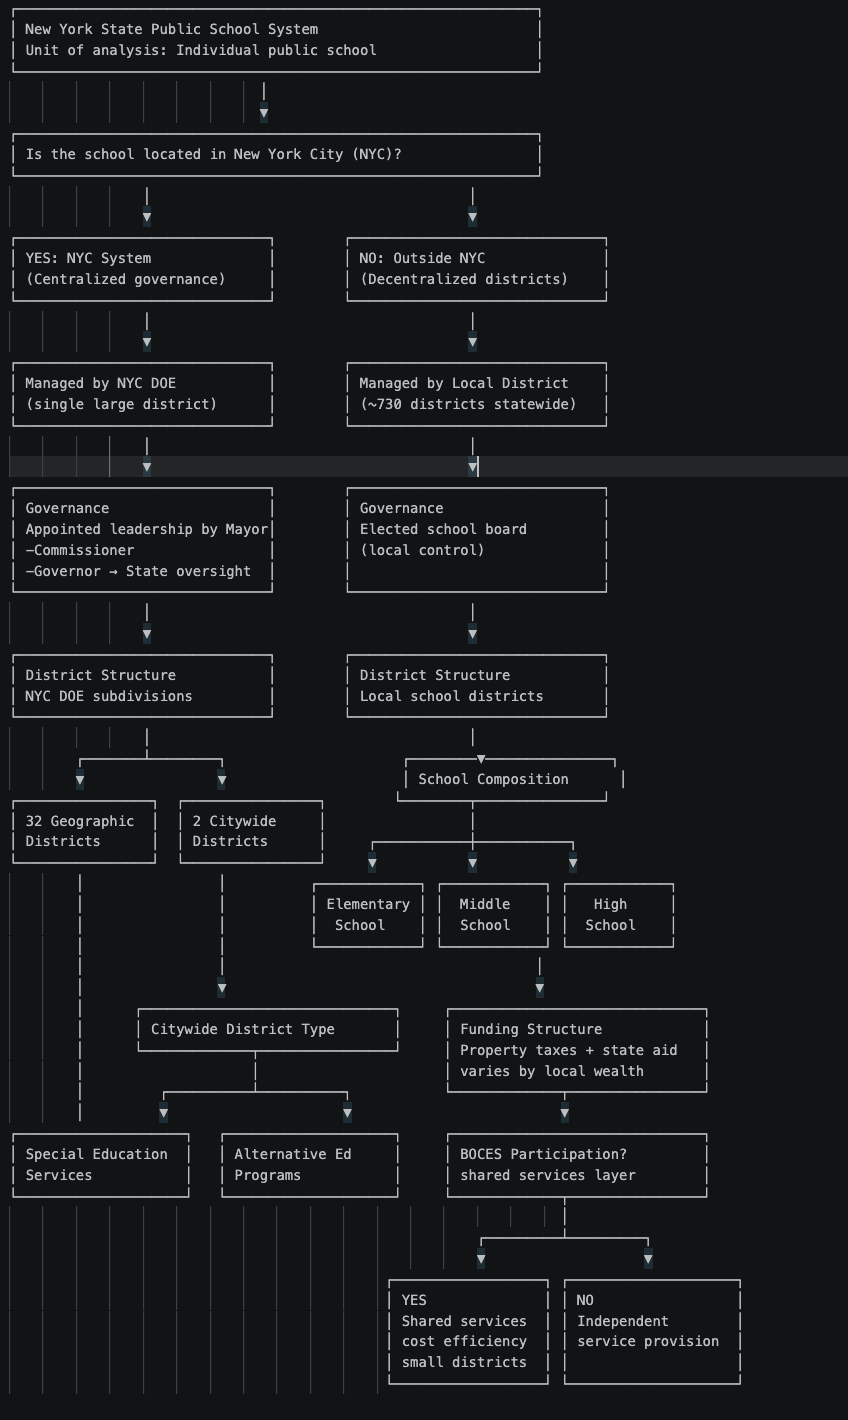

Sample EDA workflow:
1. Load
2. Inspect shape, types, missingness
3. Validate values against codebook/domain knowledge
4. Clean special codes and impossible values
5. Create useful derived variables
6. Explore distributions with histograms, PMFs, PDFs, and CDFs
7. Compare groups
8. Quantify differences with effect sizes
9. Explore relationships with scatterplots/correlation/regression
10. Use bootstrap/permutation methods for uncertainty
11. Summarize findings clearly

In [ ]:
# Load data

import pandas as pd

TRAINING_SET = pd.read_csv(
   "https://michael-weylandt.com/STA9890/competition_data/scores_training.csv"
)

TEST_SET = pd.read_csv(
   "https://michael-weylandt.com/STA9890/competition_data/scores_test.csv"
)

MEAN_PROFICIENCY =  TRAINING_SET["PERCENT_PROFICIENT"].mean()

TEST_SET[["ASSESSMENT_ID"]].\
    assign(PERCENT_PROFICIENT=MEAN_PROFICIENCY).\
    to_csv("intercept_model_for_kaggle_py.csv", 
           index=False)

SCHOOLS_INFO = pd.read_csv(
    "https://michael-weylandt.com/STA9890/competition_data/school_covariates.csv"
)

COUNTY_AVERAGES = TRAINING_SET.\
    merge(SCHOOLS_INFO, on="SCHOOL", how="inner").\
    groupby(["COUNTY", "SUBGROUP_NAME", "ASSESSMENT_NAME"], 
            as_index=False).\
    agg(PERCENT_PROFICIENT=("PERCENT_PROFICIENT", "mean"))


TEST_PREDICTIONS = TEST_SET.\
    merge(SCHOOLS_INFO, on="SCHOOL", how="inner").\
    loc[:, ["ASSESSMENT_ID", "ASSESSMENT_NAME", "COUNTY", "SUBGROUP_NAME"]].\
    merge(COUNTY_AVERAGES, on=["COUNTY", "SUBGROUP_NAME", "ASSESSMENT_NAME"], how="left")

TEST_PREDICTIONS["PERCENT_PROFICIENT"] = TEST_PREDICTIONS["PERCENT_PROFICIENT"].fillna(MEAN_PROFICIENCY)

TEST_PREDICTIONS[["ASSESSMENT_ID", "PERCENT_PROFICIENT"]].to_csv(
    "county_averages_model_for_kaggle_py.csv",
    index=False
)

In [2]:
%pip install seaborn

# Core setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)


Note: you may need to restart the kernel to use updated packages.


In [3]:
SCHOOLS_INFO.head()



,SCHOOL,DISTRICT,COUNTY,DISTRICT_TYPE,REGION,ATTENDANCE_RATE,LANGUAGE_ARTS_AVERAGE_CLASS_SIZE,MATHEMATICS_AVERAGE_CLASS_SIZE,SCIENCE_AVERAGE_CLASS_SIZE,HISTORY_GOVERNMENT_AND_GEOGRAPHY_AVERAGE_CLASS_SIZE,GRADE_1_AVERAGE_CLASS_SIZE,GRADE_2_AVERAGE_CLASS_SIZE,KINDERGARTEN_AVERAGE_CLASS_SIZE,PERCENT_FREE_LUNCH,PERCENT_REDUCED_LUNCH,NUMBER_OF_TEACHERS,NUMBER_OF_COUNSELORS,NUMBER_OF_SOCIAL_WORKERS,TEACHER_TURNOVER_RATE,PERCENT_OF_STUDENTS_SUSPENDED,N_PUPILS,FEDERAL_FUNDING_PER_PUPIL,LOCAL_FUNDING_PER_PUPIL,PRE_K,K,GRADE_01,GRADE_02,GRADE_03,GRADE_04,GRADE_05,GRADE_06,GRADE_07,GRADE_08,GRADE_09,GRADE_10,GRADE_11,GRADE_12,PERCENT_MALE,PERCENT_FEMALE,PERCENT_ENGLISH_LANGUAGE_LEANERS,PERCENT_AMERICAN_INDIAN,PERCENT_BLACK,PERCENT_ASIAN,PERCENT_HISPANIC,PERCENT_WHITE,PERCENT_MULTIRACIAL,PERCENT_WITH_DISABILITIES,PERCENT_ECONOMICALLY_DISADVANTAGED,PERCENT_MIGRANT,PERCENT_HOMELESS,PERCENT_IN_FOSTER_CARE,PERCENT_PARENT_ARMED_FORCES
0,200cb9f4,f5a6cc88,ec3f85d5,High-Need Urban/Suburban,"Capital District, New York",95.0,23.000000,23.000000,21.0,NaN,NaN,NaN,NaN,36.0,0.0,29.0,0.0,1.0,NaN,0.0,324.0,4087.0,30054.0,32.0,51.0,48.0,49.0,49.0,47.0,42.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,52.0,48.0,5.0,0.0,22.0,13.0,11.0,43.0,11.0,10.0,36.0,0.0,1.0,0.0,0.0
1,fe6c45ae,f5a6cc88,ec3f85d5,High-Need Urban/Suburban,"Capital District, New York",92.0,12.000000,12.333333,12.0,NaN,NaN,NaN,NaN,76.0,0.0,55.0,0.0,1.0,NaN,3.0,347.0,4447.0,30340.0,0.0,55.0,68.0,57.0,45.0,63.0,59.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,54.0,46.0,25.0,0.0,36.0,15.0,22.0,19.0,8.0,15.0,76.0,0.0,4.0,2.0,0.0
2,edd71301,f5a6cc88,ec3f85d5,High-Need Urban/Suburban,"Capital District, New York",91.0,11.666667,11.666667,11.0,NaN,NaN,NaN,NaN,84.0,0.0,49.0,0.0,1.0,NaN,1.0,311.0,3529.0,24776.0,20.0,51.0,49.0,52.0,52.0,45.0,42.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,53.0,47.0,30.0,1.0,32.0,17.0,35.0,9.0,7.0,5.0,84.0,0.0,3.0,0.0,0.0
3,f3fc11ad,f5a6cc88,ec3f85d5,High-Need Urban/Suburban,"Capital District, New York",94.0,13.000000,13.000000,15.0,NaN,NaN,NaN,NaN,48.0,0.0,61.0,0.0,2.0,NaN,1.0,459.0,3973.0,30560.0,0.0,72.0,87.0,85.0,63.0,79.0,73.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,52.0,48.0,13.0,0.0,23.0,12.0,15.0,38.0,11.0,14.0,48.0,0.0,2.0,0.0,0.0
4,6f19e0a6,f5a6cc88,ec3f85d5,High-Need Urban/Suburban,"Capital District, New York",93.0,19.666667,19.666667,23.0,NaN,NaN,NaN,NaN,60.0,0.0,40.0,0.0,1.0,NaN,0.0,332.0,4919.0,36513.0,0.0,41.0,58.0,56.0,51.0,58.0,46.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,44.0,56.0,5.0,0.0,43.0,10.0,17.0,18.0,11.0,13.0,60.0,0.0,6.0,0.0,0.0


In [4]:
TRAINING_SET.head()

,ASSESSMENT_ID,SCHOOL,SUBGROUP_NAME,ASSESSMENT_NAME,N_STUDENTS,PERCENT_PROFICIENT
0,3b6deef53665,e037d064,Economically Disadvantaged,ELA4,130,38
1,962a3bfbfe84,5f633522,Male,ELA6,23,65
2,ffe086287b6e,2b76539e,All Students,Regents Algebra I,94,65
3,e6f80847409d,31289ced,All Students,MATH6,56,52
4,676cc6d81961,219db6e5,All Students,ELA8,134,46



A training set of 144921 are provided for you to build your models. The target variable for this data set is PERCENT_PROFICIENT, which ranges from 0 to 100. Scores here are reported for 4469 different schools (SCHOOL), 5 different subpopulations SUBGROUP_NAME, and 32different standardized assessments (ASSESSMENT_NAME). The SCHOOL column can be used to connect this data with the school-level covariates provided above.

We see here a rough bell curve in the overall population (with several artifacts resulting from the ‘discreteness’ of test scores), systematic underperformance of students from economically disadvantaged households, and a slight, but statistically significant, overperformance by female students.

The ASSESSMENT_ID column is a unique identifier used to identify a unique combination of (SCHOOL, SUBGROUP_NAME, ASSESSMENT_NAME). This will be used to organize your submissions on Kaggle, but is not of interest otherwise.

Finally, I also provide you with N_STUDENTS, the number of students who took each exam.

In [ ]:
TEST_SET.head()

# note the test will require various joins later in order to be usable with our engineered feature space, also not sure if i need to drop school, also might need to join with Assssment ID and school name but we dropped iit later COME BACK TO THIS!!! 
# the train and test datasets must have the same feature space, for a machine learning model to function correctly!

,ASSESSMENT_ID,SCHOOL,SUBGROUP_NAME,ASSESSMENT_NAME,N_STUDENTS
0,8af5e0382a81,a49eed66,Not Economically Disadvantaged,Regents Phy Set/Earth Sci,5
1,e1591bf8db41,022f98d2,Economically Disadvantaged,MATH6,21
2,547ec44dcea6,255d51d5,All Students,MATH3,84
3,0e200399fc40,9442d8c4,Not Economically Disadvantaged,ELA7,7
4,c2c40438dac7,3f8e3d7a,Male,Regents US History&Gov't (Framework),44


ASSESSMENT_ID is basically a compressed label for a specific combination like:


-school


-subgroup


-assessment name

In [6]:
# Number of unique schools
schools_info_unique = SCHOOLS_INFO['SCHOOL'].nunique()
training_unique = TRAINING_SET['SCHOOL'].nunique()

print("no. of unique schools in schools info vs training data set\n",
    schools_info_unique, training_unique)

print("set difference",schools_info_unique-training_unique, "schools")

# Compare with total rows
print("\ncomparison\n",len(SCHOOLS_INFO), len(TRAINING_SET))

no. of unique schools in schools info vs training data set
 4754 4469
set difference 285 schools

comparison
 4754 144921


We will consider dropping these 285 schools later because they do not appear in the training dataset, meaning they provide no usable information for modeling or analysis tied to the training data.

The dataset dimensions confirm a one-to-many structure: SCHOOLS_INFO has 4754 rows (one per school), while TRAINING_SET has 144,921 rows, indicating multiple observations per school.

In [7]:
schools_info_set = set(SCHOOLS_INFO['SCHOOL'])
training_set = set(TRAINING_SET['SCHOOL'])

# Schools in training but not in info
missing_in_info = training_set - schools_info_set

# Schools in info but not in training
missing_in_training = schools_info_set - training_set

print(len(missing_in_info), len(missing_in_training))

0 285


In [8]:
SCHOOLS_INFO['SCHOOL'].is_unique

# Perfect clean 1-many join

True

Twe join below merges the two tables so that we can perform analysis smoothly

In [9]:
merged = TRAINING_SET.merge(SCHOOLS_INFO, on='SCHOOL', how='left')


In [10]:
merged[merged['SCHOOL'] == 'e037d064'].head() # Sample Sanity check for a school



,ASSESSMENT_ID,SCHOOL,SUBGROUP_NAME,ASSESSMENT_NAME,N_STUDENTS,PERCENT_PROFICIENT,DISTRICT,COUNTY,DISTRICT_TYPE,REGION,ATTENDANCE_RATE,LANGUAGE_ARTS_AVERAGE_CLASS_SIZE,MATHEMATICS_AVERAGE_CLASS_SIZE,SCIENCE_AVERAGE_CLASS_SIZE,HISTORY_GOVERNMENT_AND_GEOGRAPHY_AVERAGE_CLASS_SIZE,GRADE_1_AVERAGE_CLASS_SIZE,GRADE_2_AVERAGE_CLASS_SIZE,KINDERGARTEN_AVERAGE_CLASS_SIZE,PERCENT_FREE_LUNCH,PERCENT_REDUCED_LUNCH,NUMBER_OF_TEACHERS,NUMBER_OF_COUNSELORS,NUMBER_OF_SOCIAL_WORKERS,TEACHER_TURNOVER_RATE,PERCENT_OF_STUDENTS_SUSPENDED,N_PUPILS,FEDERAL_FUNDING_PER_PUPIL,LOCAL_FUNDING_PER_PUPIL,PRE_K,K,GRADE_01,GRADE_02,GRADE_03,GRADE_04,GRADE_05,GRADE_06,GRADE_07,GRADE_08,GRADE_09,GRADE_10,GRADE_11,GRADE_12,PERCENT_MALE,PERCENT_FEMALE,PERCENT_ENGLISH_LANGUAGE_LEANERS,PERCENT_AMERICAN_INDIAN,PERCENT_BLACK,PERCENT_ASIAN,PERCENT_HISPANIC,PERCENT_WHITE,PERCENT_MULTIRACIAL,PERCENT_WITH_DISABILITIES,PERCENT_ECONOMICALLY_DISADVANTAGED,PERCENT_MIGRANT,PERCENT_HOMELESS,PERCENT_IN_FOSTER_CARE,PERCENT_PARENT_ARMED_FORCES
0,3b6deef53665,e037d064,Economically Disadvantaged,ELA4,130,38,5ccd3c25,8af58576,NYC,New York City,92.0,13.0,19.333333,23.0,NaN,21.0,25.0,17.0,90.0,2.0,122.0,3.0,1.0,NaN,0.0,1126.0,4168.0,27801.0,14.0,139.0,182.0,175.0,206.0,202.0,208.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,53.0,47.0,48.0,0.0,1.0,19.0,78.0,2.0,1.0,20.0,92.0,0.0,17.0,0.0,1.0
4085,00cb4d5ca301,e037d064,Female,MATH4,74,43,5ccd3c25,8af58576,NYC,New York City,92.0,13.0,19.333333,23.0,NaN,21.0,25.0,17.0,90.0,2.0,122.0,3.0,1.0,NaN,0.0,1126.0,4168.0,27801.0,14.0,139.0,182.0,175.0,206.0,202.0,208.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,53.0,47.0,48.0,0.0,1.0,19.0,78.0,2.0,1.0,20.0,92.0,0.0,17.0,0.0,1.0
15350,0db53b37a7a7,e037d064,All Students,ELA5,170,35,5ccd3c25,8af58576,NYC,New York City,92.0,13.0,19.333333,23.0,NaN,21.0,25.0,17.0,90.0,2.0,122.0,3.0,1.0,NaN,0.0,1126.0,4168.0,27801.0,14.0,139.0,182.0,175.0,206.0,202.0,208.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,53.0,47.0,48.0,0.0,1.0,19.0,78.0,2.0,1.0,20.0,92.0,0.0,17.0,0.0,1.0
15983,5658c0806cc9,e037d064,Not Economically Disadvantaged,MATH5,14,14,5ccd3c25,8af58576,NYC,New York City,92.0,13.0,19.333333,23.0,NaN,21.0,25.0,17.0,90.0,2.0,122.0,3.0,1.0,NaN,0.0,1126.0,4168.0,27801.0,14.0,139.0,182.0,175.0,206.0,202.0,208.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,53.0,47.0,48.0,0.0,1.0,19.0,78.0,2.0,1.0,20.0,92.0,0.0,17.0,0.0,1.0
18285,090e513f3e74,e037d064,Not Economically Disadvantaged,ELA5,14,14,5ccd3c25,8af58576,NYC,New York City,92.0,13.0,19.333333,23.0,NaN,21.0,25.0,17.0,90.0,2.0,122.0,3.0,1.0,NaN,0.0,1126.0,4168.0,27801.0,14.0,139.0,182.0,175.0,206.0,202.0,208.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,53.0,47.0,48.0,0.0,1.0,19.0,78.0,2.0,1.0,20.0,92.0,0.0,17.0,0.0,1.0


In [11]:
df = merged

# Assessment ID is redundant since the encoding also in test set
df = df.drop(columns=["ASSESSMENT_ID"]) 



In [12]:
# Basic structure
print(df.shape)
print(df.info())


(144921, 56)
<class 'pandas.DataFrame'>
RangeIndex: 144921 entries, 0 to 144920
Data columns (total 56 columns):
 #   Column                                               Non-Null Count   Dtype  
---  ------                                               --------------   -----  
 0   SCHOOL                                               144921 non-null  str    
 1   SUBGROUP_NAME                                        144921 non-null  str    
 2   ASSESSMENT_NAME                                      144921 non-null  str    
 3   N_STUDENTS                                           144921 non-null  int64  
 4   PERCENT_PROFICIENT                                   144921 non-null  int64  
 5   DISTRICT                                             144921 non-null  str    
 6   COUNTY                                               144921 non-null  str    
 7   DISTRICT_TYPE                                        144921 non-null  str    
 8   REGION                                              

In [13]:
# missingness analysis

missing = df.isna().sum().to_frame(name="missing_count")
missing["missing_pct"] = (missing["missing_count"] / len(df)) * 100

missing = missing.sort_values(by="missing_pct", ascending=False)

missing

,missing_count,missing_pct
TEACHER_TURNOVER_RATE,134136,92.558014
KINDERGARTEN_AVERAGE_CLASS_SIZE,103467,71.395450
GRADE_1_AVERAGE_CLASS_SIZE,102899,71.003512
GRADE_2_AVERAGE_CLASS_SIZE,102779,70.920709
HISTORY_GOVERNMENT_AND_GEOGRAPHY_AVERAGE_CLASS_SIZE,89314,61.629439
SCIENCE_AVERAGE_CLASS_SIZE,8475,5.848014
LANGUAGE_ARTS_AVERAGE_CLASS_SIZE,7156,4.937863
MATHEMATICS_AVERAGE_CLASS_SIZE,3795,2.618668
N_PUPILS,3646,2.515853
FEDERAL_FUNDING_PER_PUPIL,3646,2.515853


### Missingness Check

The following features have **60–93% missing values**:

* `TEACHER_TURNOVER_RATE`
* `KINDERGARTEN_AVERAGE_CLASS_SIZE`
* `GRADE_1_AVERAGE_CLASS_SIZE`
* `GRADE_2_AVERAGE_CLASS_SIZE`
* `HISTORY_GOVERNMENT_AND_GEOGRAPHY_AVERAGE_CLASS_SIZE`

→ Dropped due to extreme sparsity


In [14]:
cols_to_drop = [
    "TEACHER_TURNOVER_RATE",
    "KINDERGARTEN_AVERAGE_CLASS_SIZE",
    "GRADE_1_AVERAGE_CLASS_SIZE",
    "GRADE_2_AVERAGE_CLASS_SIZE",
    "HISTORY_GOVERNMENT_AND_GEOGRAPHY_AVERAGE_CLASS_SIZE"
]

df = df.drop(columns=cols_to_drop)


# missingness analysis

missing = df.isna().sum().to_frame(name="missing_count")
missing["missing_pct"] = (missing["missing_count"] / len(df)) * 100

missing = missing.sort_values(by="missing_pct", ascending=False)

missing.head()

,missing_count,missing_pct
SCIENCE_AVERAGE_CLASS_SIZE,8475,5.848014
LANGUAGE_ARTS_AVERAGE_CLASS_SIZE,7156,4.937863
MATHEMATICS_AVERAGE_CLASS_SIZE,3795,2.618668
LOCAL_FUNDING_PER_PUPIL,3646,2.515853
FEDERAL_FUNDING_PER_PUPIL,3646,2.515853


In [15]:
# Basic structure recheck
print(df.shape)
print(df.info())

(144921, 51)
<class 'pandas.DataFrame'>
RangeIndex: 144921 entries, 0 to 144920
Data columns (total 51 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   SCHOOL                              144921 non-null  str    
 1   SUBGROUP_NAME                       144921 non-null  str    
 2   ASSESSMENT_NAME                     144921 non-null  str    
 3   N_STUDENTS                          144921 non-null  int64  
 4   PERCENT_PROFICIENT                  144921 non-null  int64  
 5   DISTRICT                            144921 non-null  str    
 6   COUNTY                              144921 non-null  str    
 7   DISTRICT_TYPE                       144921 non-null  str    
 8   REGION                              144921 non-null  str    
 9   ATTENDANCE_RATE                     141885 non-null  float64
 10  LANGUAGE_ARTS_AVERAGE_CLASS_SIZE    137765 non-null  float64
 11  MATHEMATICS_AVERAGE_CLAS

In [16]:
# More basic structure sanity check

print(df.describe(include="all").T)
df.sample(5)

                                       count unique            top   freq          mean          std   min        25%  \
SCHOOL                                144921   4469       6f557320    100           NaN          NaN   NaN        NaN   
SUBGROUP_NAME                         144921      5   All Students  36711           NaN          NaN   NaN        NaN   
ASSESSMENT_NAME                       144921     32           ELA3   8392           NaN          NaN   NaN        NaN   
N_STUDENTS                          144921.0    NaN            NaN    NaN     57.664748    67.211682   5.0       21.0   
PERCENT_PROFICIENT                  144921.0    NaN            NaN    NaN     54.183521    26.429925   0.0       33.0   
DISTRICT                              144921    710       03759bb1  13986           NaN          NaN   NaN        NaN   
COUNTY                                144921     62       062c154c  17112           NaN          NaN   NaN        NaN   
DISTRICT_TYPE                   

,SCHOOL,SUBGROUP_NAME,ASSESSMENT_NAME,N_STUDENTS,PERCENT_PROFICIENT,DISTRICT,COUNTY,DISTRICT_TYPE,REGION,ATTENDANCE_RATE,LANGUAGE_ARTS_AVERAGE_CLASS_SIZE,MATHEMATICS_AVERAGE_CLASS_SIZE,SCIENCE_AVERAGE_CLASS_SIZE,PERCENT_FREE_LUNCH,PERCENT_REDUCED_LUNCH,NUMBER_OF_TEACHERS,NUMBER_OF_COUNSELORS,NUMBER_OF_SOCIAL_WORKERS,PERCENT_OF_STUDENTS_SUSPENDED,N_PUPILS,FEDERAL_FUNDING_PER_PUPIL,LOCAL_FUNDING_PER_PUPIL,PRE_K,K,GRADE_01,GRADE_02,GRADE_03,GRADE_04,GRADE_05,GRADE_06,GRADE_07,GRADE_08,GRADE_09,GRADE_10,GRADE_11,GRADE_12,PERCENT_MALE,PERCENT_FEMALE,PERCENT_ENGLISH_LANGUAGE_LEANERS,PERCENT_AMERICAN_INDIAN,PERCENT_BLACK,PERCENT_ASIAN,PERCENT_HISPANIC,PERCENT_WHITE,PERCENT_MULTIRACIAL,PERCENT_WITH_DISABILITIES,PERCENT_ECONOMICALLY_DISADVANTAGED,PERCENT_MIGRANT,PERCENT_HOMELESS,PERCENT_IN_FOSTER_CARE,PERCENT_PARENT_ARMED_FORCES
129289,123aa3de,Not Economically Disadvantaged,Regents US History&Gov't (Framework),9,67,067f6965,613b61ae,NYC,New York City,84.0,NaN,22.000,26.00,89.0,2.0,28.0,2.0,0.0,0.0,323.0,4873.0,23522.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,82.0,74.0,82.0,85.0,48.0,52.0,10.0,1.0,19.0,1.0,77.0,1.0,1.0,29.0,91.0,0.0,10.0,0.0,0.0
86580,fd79f092,Female,MATH3,36,92,93df5d67,26ea5314,Low Need,Hudson Valley,95.0,18.000000,18.000,19.00,15.0,1.0,50.0,1.0,0.0,0.0,506.0,754.0,32042.0,0.0,68.0,83.0,84.0,88.0,86.0,94.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,48.0,52.0,7.0,1.0,8.0,7.0,17.0,63.0,4.0,17.0,17.0,0.0,0.0,0.0,0.0
8854,9e35d0ef,Male,Regents Common Core Geometry,68,13,03759bb1,26ea5314,Charter School,Hudson Valley,95.0,26.285714,26.875,26.00,71.0,16.0,58.0,2.0,0.0,4.0,1124.0,2371.0,16115.0,0.0,79.0,83.0,83.0,83.0,84.0,83.0,83.0,82.0,81.0,104.0,101.0,93.0,85.0,48.0,52.0,14.0,0.0,41.0,2.0,54.0,1.0,2.0,5.0,87.0,0.0,1.0,0.0,0.0
26994,38592bbf,Male,Regents Phy Set/Earth Sci,14,21,05c15737,613b61ae,NYC,New York City,92.0,19.000000,23.000,17.75,80.0,8.0,46.0,2.0,1.0,0.0,350.0,5283.0,25312.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,80.0,85.0,90.0,95.0,26.0,74.0,1.0,1.0,29.0,3.0,63.0,3.0,1.0,20.0,88.0,0.0,9.0,0.0,0.0
117014,e2cb78a9,Male,MATH3,56,43,067f6965,613b61ae,NYC,New York City,91.0,11.666667,19.000,24.00,93.0,2.0,63.0,1.0,2.0,0.0,831.0,5392.0,25685.0,11.0,127.0,146.0,130.0,123.0,147.0,145.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,52.0,48.0,32.0,2.0,16.0,16.0,63.0,2.0,1.0,17.0,95.0,0.0,13.0,1.0,0.0


In [17]:
# Column names and data types
print(df.columns)
len(df.columns)


Index(['SCHOOL', 'SUBGROUP_NAME', 'ASSESSMENT_NAME', 'N_STUDENTS', 'PERCENT_PROFICIENT', 'DISTRICT', 'COUNTY',
       'DISTRICT_TYPE', 'REGION', 'ATTENDANCE_RATE', 'LANGUAGE_ARTS_AVERAGE_CLASS_SIZE',
       'MATHEMATICS_AVERAGE_CLASS_SIZE', 'SCIENCE_AVERAGE_CLASS_SIZE', 'PERCENT_FREE_LUNCH', 'PERCENT_REDUCED_LUNCH',
       'NUMBER_OF_TEACHERS', 'NUMBER_OF_COUNSELORS', 'NUMBER_OF_SOCIAL_WORKERS', 'PERCENT_OF_STUDENTS_SUSPENDED',
       'N_PUPILS', 'FEDERAL_FUNDING_PER_PUPIL', 'LOCAL_FUNDING_PER_PUPIL', 'PRE_K', 'K', 'GRADE_01', 'GRADE_02',
       'GRADE_03', 'GRADE_04', 'GRADE_05', 'GRADE_06', 'GRADE_07', 'GRADE_08', 'GRADE_09', 'GRADE_10', 'GRADE_11',
       'GRADE_12', 'PERCENT_MALE', 'PERCENT_FEMALE', 'PERCENT_ENGLISH_LANGUAGE_LEANERS', 'PERCENT_AMERICAN_INDIAN',
       'PERCENT_BLACK', 'PERCENT_ASIAN', 'PERCENT_HISPANIC', 'PERCENT_WHITE', 'PERCENT_MULTIRACIAL',
       'PERCENT_WITH_DISABILITIES', 'PERCENT_ECONOMICALLY_DISADVANTAGED', 'PERCENT_MIGRANT', 'PERCENT_HOMELESS',
       'PE

51

In [18]:
print(df.nunique().sort_values())

SUBGROUP_NAME                            5
DISTRICT_TYPE                            7
PERCENT_IN_FOSTER_CARE                   8
REGION                                  10
PERCENT_MIGRANT                         11
NUMBER_OF_SOCIAL_WORKERS                14
PERCENT_REDUCED_LUNCH                   20
NUMBER_OF_COUNSELORS                    21
PERCENT_PARENT_ARMED_FORCES             23
PERCENT_MULTIRACIAL                     24
ASSESSMENT_NAME                         32
PERCENT_AMERICAN_INDIAN                 34
PERCENT_OF_STUDENTS_SUSPENDED           43
ATTENDANCE_RATE                         58
PERCENT_WITH_DISABILITIES               61
COUNTY                                  62
PERCENT_HOMELESS                        62
PERCENT_FEMALE                          68
PERCENT_MALE                            69
PERCENT_ENGLISH_LANGUAGE_LEANERS        86
PERCENT_ASIAN                           89
PERCENT_BLACK                           92
PERCENT_WHITE                          101
PERCENT_HIS

In [19]:
# Cardinality analysis of categorical variables
cat_cols = df.select_dtypes(include="str").columns

df[cat_cols].nunique().sort_values()

SUBGROUP_NAME         5
DISTRICT_TYPE         7
REGION               10
ASSESSMENT_NAME      32
COUNTY               62
DISTRICT            710
SCHOOL             4469
dtype: int64

### Categorical Cardinality

* **Low cardinality:**
  `SUBGROUP_NAME` (5), `DISTRICT_TYPE` (7), `REGION` (10)

* **Moderate:**
  `ASSESSMENT_NAME` (32), `COUNTY` (62)

* **High cardinality:**
  `DISTRICT` (710), `SCHOOL` (4469)

### Notes

* Low → suitable for one-hot encoding
* High → may require alternative handling (or exclusion)

Something we need to consider regarding the high cardinality covariates is that they are all location data so dropping them may make us lose signal generated from location.


However including them contains high overfitting risk and feature explosion. We have to think of a middle ground but for now we dump `DISTRICT` (710), `SCHOOL` (4469). We only include them back in if model performance MSE is lacking

In [20]:
low_med_cat = ["SUBGROUP_NAME", "DISTRICT_TYPE", "REGION", "ASSESSMENT_NAME", "COUNTY"]  # only double digit cardinality ones

for col in low_med_cat:
    print(f"\n{col}:")
    print(df[col].unique())


SUBGROUP_NAME:
<StringArray>
['Economically Disadvantaged', 'Male', 'All Students', 'Not Economically Disadvantaged', 'Female']
Length: 5, dtype: str

DISTRICT_TYPE:
<StringArray>
['NYC', 'Other Large City', 'Average Need', 'Charter School', 'High-Need Rural', 'Low Need',
 'High-Need Urban/Suburban']
Length: 7, dtype: str

REGION:
<StringArray>
[             'New York City',              'Hudson Valley', 'Capital District, New York',
              'Mohawk Valley',              'Southern Tier',           'Western New York',
           'Central New York',               'Finger Lakes',                'Long Island',
   'North Country (New York)']
Length: 10, dtype: str

ASSESSMENT_NAME:
<StringArray>
[                                    'ELA4',                                     'ELA6',
                        'Regents Algebra I',                                    'MATH6',
                                     'ELA8',                                    'MATH4',
 'Regents Common Core Engl

### The next cell reengineers the high cardinality variables into new quantitative variables and then drops the previous high cardinality versions

In [ ]:
# Frequency encoding
df["school_freq"] = df["SCHOOL"].map(df["SCHOOL"].value_counts())
df["district_freq"] = df["DISTRICT"].map(df["DISTRICT"].value_counts())



#### BEFORE DROPPING below THINK ABOUT FIRST JOIN FOR TEST DATA SET,COME BACK TO THIS LATER!!
# Now drop the raw ID columns
df = df.drop(columns=["DISTRICT", "SCHOOL"])



SCHOOL and DISTRICT are high-cardinality categorical variables. To preserve some location-level information without creating thousands of dummy variables, frequency encoding was used. This replaces each school and district with the number of times it appears in the dataset. Target encoding was avoided at this stage because it uses the response variable and may introduce target leakage or bias model evaluation.

In [22]:
# Column names and data types
print(df.columns)
len(df.columns)


Index(['SUBGROUP_NAME', 'ASSESSMENT_NAME', 'N_STUDENTS', 'PERCENT_PROFICIENT', 'COUNTY', 'DISTRICT_TYPE', 'REGION',
       'ATTENDANCE_RATE', 'LANGUAGE_ARTS_AVERAGE_CLASS_SIZE', 'MATHEMATICS_AVERAGE_CLASS_SIZE',
       'SCIENCE_AVERAGE_CLASS_SIZE', 'PERCENT_FREE_LUNCH', 'PERCENT_REDUCED_LUNCH', 'NUMBER_OF_TEACHERS',
       'NUMBER_OF_COUNSELORS', 'NUMBER_OF_SOCIAL_WORKERS', 'PERCENT_OF_STUDENTS_SUSPENDED', 'N_PUPILS',
       'FEDERAL_FUNDING_PER_PUPIL', 'LOCAL_FUNDING_PER_PUPIL', 'PRE_K', 'K', 'GRADE_01', 'GRADE_02', 'GRADE_03',
       'GRADE_04', 'GRADE_05', 'GRADE_06', 'GRADE_07', 'GRADE_08', 'GRADE_09', 'GRADE_10', 'GRADE_11', 'GRADE_12',
       'PERCENT_MALE', 'PERCENT_FEMALE', 'PERCENT_ENGLISH_LANGUAGE_LEANERS', 'PERCENT_AMERICAN_INDIAN',
       'PERCENT_BLACK', 'PERCENT_ASIAN', 'PERCENT_HISPANIC', 'PERCENT_WHITE', 'PERCENT_MULTIRACIAL',
       'PERCENT_WITH_DISABILITIES', 'PERCENT_ECONOMICALLY_DISADVANTAGED', 'PERCENT_MIGRANT', 'PERCENT_HOMELESS',
       'PERCENT_IN_FOSTER_CARE',

51

### Column analysis currently

51-response = 50 covariates total

In [23]:
df.head()


,SUBGROUP_NAME,ASSESSMENT_NAME,N_STUDENTS,PERCENT_PROFICIENT,COUNTY,DISTRICT_TYPE,REGION,ATTENDANCE_RATE,LANGUAGE_ARTS_AVERAGE_CLASS_SIZE,MATHEMATICS_AVERAGE_CLASS_SIZE,SCIENCE_AVERAGE_CLASS_SIZE,PERCENT_FREE_LUNCH,PERCENT_REDUCED_LUNCH,NUMBER_OF_TEACHERS,NUMBER_OF_COUNSELORS,NUMBER_OF_SOCIAL_WORKERS,PERCENT_OF_STUDENTS_SUSPENDED,N_PUPILS,FEDERAL_FUNDING_PER_PUPIL,LOCAL_FUNDING_PER_PUPIL,PRE_K,K,GRADE_01,GRADE_02,GRADE_03,GRADE_04,GRADE_05,GRADE_06,GRADE_07,GRADE_08,GRADE_09,GRADE_10,GRADE_11,GRADE_12,PERCENT_MALE,PERCENT_FEMALE,PERCENT_ENGLISH_LANGUAGE_LEANERS,PERCENT_AMERICAN_INDIAN,PERCENT_BLACK,PERCENT_ASIAN,PERCENT_HISPANIC,PERCENT_WHITE,PERCENT_MULTIRACIAL,PERCENT_WITH_DISABILITIES,PERCENT_ECONOMICALLY_DISADVANTAGED,PERCENT_MIGRANT,PERCENT_HOMELESS,PERCENT_IN_FOSTER_CARE,PERCENT_PARENT_ARMED_FORCES,school_freq,district_freq
0,Economically Disadvantaged,ELA4,130,38,8af58576,NYC,New York City,92.0,13.000000,19.333333,23.0,90.0,2.0,122.0,3.0,1.0,0.0,1126.0,4168.0,27801.0,14.0,139.0,182.0,175.0,206.0,202.0,208.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,53.0,47.0,48.0,0.0,1.0,19.0,78.0,2.0,1.0,20.0,92.0,0.0,17.0,0.0,1.0,28,1771
1,Male,ELA6,23,65,26ea5314,Other Large City,Hudson Valley,94.0,28.833333,29.285714,28.0,30.0,5.0,25.0,1.0,0.0,1.0,542.0,1930.0,24749.0,36.0,52.0,52.0,57.0,58.0,58.0,58.0,59.0,58.0,54.0,0.0,0.0,0.0,0.0,47.0,53.0,2.0,0.0,7.0,6.0,38.0,44.0,5.0,28.0,35.0,0.0,0.0,0.0,0.0,58,1811
2,All Students,Regents Algebra I,94,65,496d1e32,Average Need,"Capital District, New York",93.0,15.000000,19.500000,18.0,42.0,4.0,39.0,2.0,1.0,11.0,363.0,1962.0,16852.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,99.0,100.0,78.0,80.0,50.0,50.0,0.0,0.0,0.0,0.0,1.0,97.0,2.0,11.0,50.0,0.0,2.0,0.0,1.0,42,98
3,All Students,MATH6,56,52,454cd604,Average Need,Mohawk Valley,92.0,20.000000,18.222222,16.5,44.0,6.0,46.0,1.0,0.0,4.0,567.0,783.0,28061.0,0.0,38.0,49.0,39.0,37.0,42.0,51.0,61.0,55.0,37.0,41.0,36.0,40.0,41.0,49.0,51.0,3.0,0.0,6.0,3.0,2.0,87.0,1.0,12.0,56.0,0.0,1.0,0.0,0.0,95,95
4,All Students,ELA8,134,46,0a6a5af4,Average Need,Southern Tier,97.0,29.333333,20.250000,20.5,43.0,2.0,43.0,0.0,0.0,5.0,461.0,870.0,22336.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,156.0,151.0,143.0,0.0,0.0,0.0,0.0,51.0,49.0,1.0,0.0,0.0,0.0,1.0,96.0,3.0,14.0,44.0,0.0,1.0,0.0,0.0,40,126


In [24]:
# Duplicate analysis

df.duplicated().sum()

np.int64(2)

Duplicate analysis showed 0 exact duplicate rows in the dataset. Therefore, no rows were removed at this stage.

In [26]:
cat_cols = df.select_dtypes(include=["str"]).columns
df[cat_cols].isna().sum().sort_values(ascending=False)

SUBGROUP_NAME      0
ASSESSMENT_NAME    0
COUNTY             0
DISTRICT_TYPE      0
REGION             0
dtype: int64

count    144921.000000
mean         54.183521
std          26.429925
min           0.000000
25%          33.000000
50%          53.000000
75%          76.000000
max         100.000000
Name: PERCENT_PROFICIENT, dtype: float64
0.01      0.0
0.05     13.0
0.25     33.0
0.50     53.0
0.75     76.0
0.95     98.0
0.99    100.0
Name: PERCENT_PROFICIENT, dtype: float64


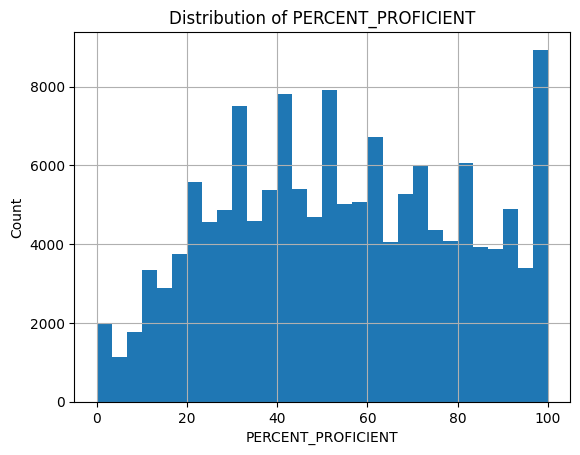

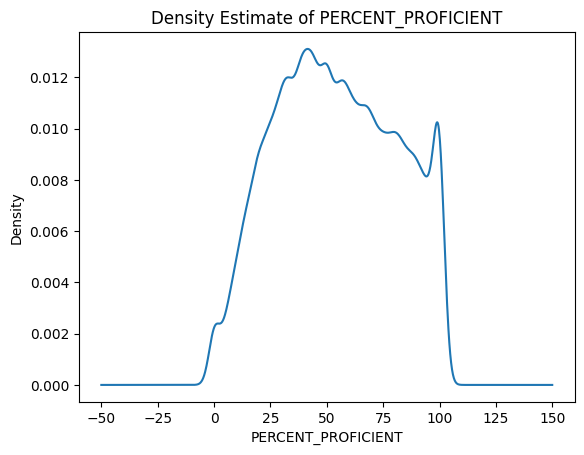

In [31]:
import matplotlib.pyplot as plt

target_col = "PERCENT_PROFICIENT"

print(df[target_col].describe())

print(df[target_col].quantile([0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]))


df[target_col].hist(bins=30)
plt.xlabel(target_col)
plt.ylabel("Count")
plt.title("Distribution of PERCENT_PROFICIENT")
plt.show()

df[target_col].plot(kind="kde")
plt.xlabel(target_col)
plt.title("Density Estimate of PERCENT_PROFICIENT")
plt.show()




The target variable PERCENT_PROFICIENT ranges from 0 to 100, confirming it is a bounded percentage outcome. The distribution is roughly centered around 53–54 with substantial variability (std ≈ 26). 

There is a noticeable concentration of observations near 100, indicating a ceiling effect where many schools achieve very high proficiency rates. Additionally, a small portion of observations lie near 0, suggesting a wide performance range across schools.

Given the relatively symmetric distribution and bounded nature, no transformation of the target variable is applied at this stage.

In [32]:
corr = df.corr(numeric_only=True)["PERCENT_PROFICIENT"].sort_values(ascending=False)
corr

PERCENT_PROFICIENT                    1.000000
ATTENDANCE_RATE                       0.259556
PERCENT_WHITE                         0.256312
PERCENT_ASIAN                         0.209061
GRADE_12                              0.193282
GRADE_11                              0.189421
GRADE_10                              0.178460
GRADE_09                              0.169469
NUMBER_OF_TEACHERS                    0.166746
NUMBER_OF_COUNSELORS                  0.166693
N_PUPILS                              0.159996
PERCENT_REDUCED_LUNCH                 0.124086
school_freq                           0.122495
N_STUDENTS                            0.109002
LANGUAGE_ARTS_AVERAGE_CLASS_SIZE      0.093076
MATHEMATICS_AVERAGE_CLASS_SIZE        0.086877
GRADE_07                              0.085800
GRADE_08                              0.085167
SCIENCE_AVERAGE_CLASS_SIZE            0.053376
GRADE_06                              0.042132
LOCAL_FUNDING_PER_PUPIL               0.023787
PERCENT_FEMAL

In [38]:
corr_df = (
    df.corr(numeric_only=True)["PERCENT_PROFICIENT"]
    .drop("PERCENT_PROFICIENT")
    .sort_values(ascending=False)
    .to_frame(name="correlation")
)

pos_corr = corr_df[corr_df["correlation"] > 0].sort_values(by="correlation", ascending=False)
neg_corr = corr_df[corr_df["correlation"] < 0].sort_values(by="correlation")

top_pos = pos_corr.head(10)
top_neg = neg_corr.head(10)

top_pos, top_neg


(                      correlation
 ATTENDANCE_RATE          0.259556
 PERCENT_WHITE            0.256312
 PERCENT_ASIAN            0.209061
 GRADE_12                 0.193282
 GRADE_11                 0.189421
 GRADE_10                 0.178460
 GRADE_09                 0.169469
 NUMBER_OF_TEACHERS       0.166746
 NUMBER_OF_COUNSELORS     0.166693
 N_PUPILS                 0.159996,
                                     correlation
 PERCENT_ECONOMICALLY_DISADVANTAGED    -0.430020
 PERCENT_FREE_LUNCH                    -0.421505
 PERCENT_HOMELESS                      -0.285721
 PERCENT_ENGLISH_LANGUAGE_LEANERS      -0.263726
 PERCENT_WITH_DISABILITIES             -0.263265
 PERCENT_BLACK                         -0.262749
 PERCENT_HISPANIC                      -0.244022
 PERCENT_IN_FOSTER_CARE                -0.227881
 PRE_K                                 -0.176596
 FEDERAL_FUNDING_PER_PUPIL             -0.154136)

Correlation analysis reveals that socioeconomic variables such as percent economically disadvantaged and percent free lunch have the strongest negative relationships with student proficiency. Demographic factors including percent English language learners, disabilities, and certain racial compositions also show moderate negative correlations.

On the positive side, attendance rate and some demographic proportions exhibit moderate positive relationships with performance. These results suggest that both socioeconomic conditions and school composition play a significant role in predicting proficiency outcomes.

Additionally, many of these variables appear to be related to each other, indicating potential multicollinearity that may affect linear models but can be handled through regularization or tree-based methods.

In [ ]:
# store for later if needed
eda_artifacts = {}

eda_artifacts["correlation_full"] = corr_df
eda_artifacts["correlation_positive"] = pos_corr
eda_artifacts["correlation_negative"] = neg_corr
eda_artifacts["top_positive"] = top_pos
eda_artifacts["top_negative"] = top_neg

corr_df["abs_corr"] = corr_df["correlation"].abs()
corr_ranked = corr_df.sort_values(by="abs_corr", ascending=False)

# absolute correlation ranking
corr_ranked.head(15)

,correlation,abs_corr
PERCENT_ECONOMICALLY_DISADVANTAGED,-0.430020,0.430020
PERCENT_FREE_LUNCH,-0.421505,0.421505
PERCENT_HOMELESS,-0.285721,0.285721
PERCENT_ENGLISH_LANGUAGE_LEANERS,-0.263726,0.263726
PERCENT_WITH_DISABILITIES,-0.263265,0.263265
PERCENT_BLACK,-0.262749,0.262749
ATTENDANCE_RATE,0.259556,0.259556
PERCENT_WHITE,0.256312,0.256312
PERCENT_HISPANIC,-0.244022,0.244022
PERCENT_IN_FOSTER_CARE,-0.227881,0.227881


Numeric features were evaluated based on their correlation with the target variable. The results were organized into positive and negative correlation tables, along with rankings based on absolute correlation magnitude. These tables will be used later for feature selection and model interpretation.

In [ ]:
# Grouped Analysis 1

subgroup_summary = (
    df.groupby("SUBGROUP_NAME")["PERCENT_PROFICIENT"]
    .describe()
    .sort_values(by="mean", ascending=False)
)

subgroup_summary

,count,mean,std,min,25%,50%,75%,max
SUBGROUP_NAME,,,,,,,,
Not Economically Disadvantaged,24600.0,63.411911,24.887977,0.0,45.0,66.0,84.0,100.0
All Students,36711.0,54.103838,26.213863,0.0,33.0,53.0,75.0,100.0
Female,29110.0,53.707386,26.459249,0.0,33.0,52.5,75.0,100.0
Male,29363.0,52.442189,26.534575,0.0,31.0,50.0,74.0,100.0
Economically Disadvantaged,25137.0,47.854119,25.636071,0.0,27.0,44.0,67.0,100.0


In [49]:
# Grouped Analysis 2

assessment_summary = (
    df.groupby("ASSESSMENT_NAME")["PERCENT_PROFICIENT"]
    .describe()
    .sort_values(by="mean", ascending=False)
)

assessment_summary

,count,mean,std,min,25%,50%,75%,max
ASSESSMENT_NAME,,,,,,,,
RegentsMath7,31.0,97.161290,14.064368,22.0,100.00,100.0,100.00,100.0
RegentsMath8,721.0,86.852982,22.716563,0.0,83.00,100.0,100.00,100.0
RegentsScience8,723.0,81.152144,24.930020,3.0,69.50,94.0,100.00,100.0
Regents Common Core English Language Art,4697.0,78.853098,18.033712,0.0,68.00,83.0,93.00,100.0
Regents US History&Gov't (Framework),4601.0,75.725277,20.315387,0.0,64.00,81.0,92.00,100.0
Regents NF Global History,4365.0,74.995647,19.774224,0.0,63.00,80.0,90.00,100.0
Regents Common Core Algebra II,3508.0,70.401938,29.165727,0.0,50.00,82.0,94.00,100.0
Regents Algebra I,7235.0,69.235245,28.443007,0.0,47.00,76.0,97.00,100.0
Regents Phy Set/Physics,1680.0,68.508333,27.389584,0.0,51.00,78.0,90.00,100.0


# Grouped Analysis for SUBGROUP_NAME and ASSESSMENT_NAME 
## (helps interpretability of model)

Grouped analysis by SUBGROUP_NAME reveals substantial differences in performance, particularly between economically disadvantaged and non-disadvantaged students, with a gap of approximately 15 percentage points. This confirms that socioeconomic factors play a major role in student proficiency.

Grouped analysis by ASSESSMENT_NAME shows large variation in average performance across assessments. Some assessments exhibit near-ceiling performance (e.g., Regents Math 7), while others have much lower averages (e.g., Science 5 and Science 8). This indicates that assessment type strongly influences proficiency outcomes and must be included as a feature in modeling.

These results suggest that both subgroup and assessment-level heterogeneity are critical components of the data-generating process and should be explicitly accounted for in predictive models.

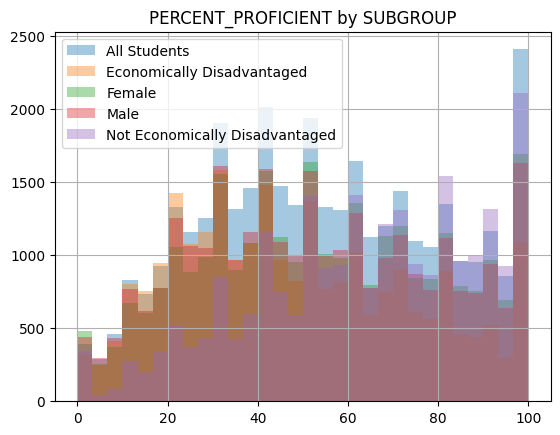

In [50]:
import matplotlib.pyplot as plt

for name, group in df.groupby("SUBGROUP_NAME"):
    group["PERCENT_PROFICIENT"].hist(alpha=0.4, bins=30, label=name)

plt.legend()
plt.title("PERCENT_PROFICIENT by SUBGROUP")
plt.show()


Plot above not helpful so we use boxplot instead

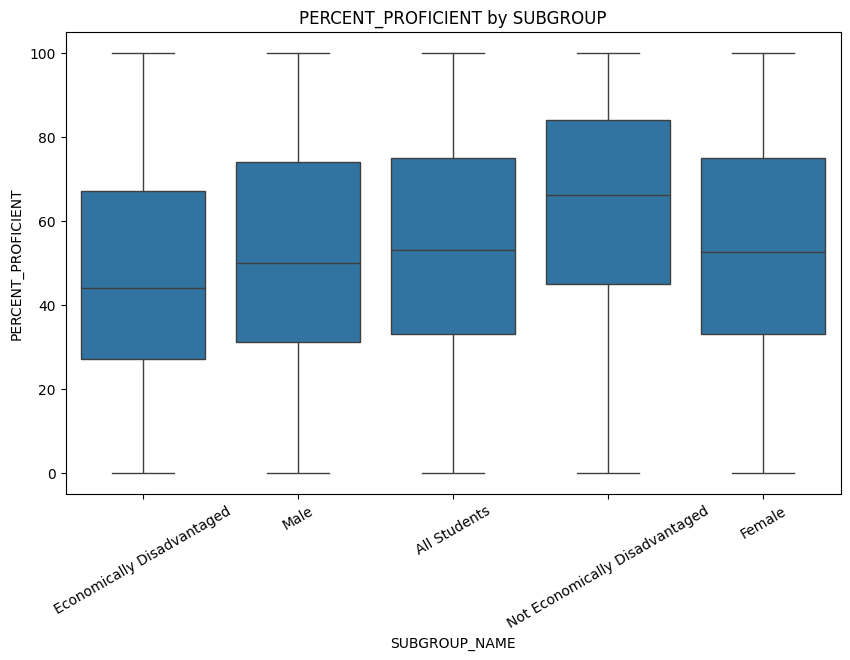

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.boxplot(x="SUBGROUP_NAME", y="PERCENT_PROFICIENT", data=df)

plt.xticks(rotation=30)
plt.title("PERCENT_PROFICIENT by SUBGROUP")
plt.show()

Exploratory data analysis revealed several key patterns in the dataset. The target variable, PERCENT_PROFICIENT, is a bounded percentage with substantial variability and a mild ceiling effect near 100.

Correlation analysis showed that socioeconomic indicators, particularly percent economically disadvantaged and percent free lunch, have strong negative relationships with student performance. Attendance and certain demographic variables exhibit moderate positive relationships.

Grouped analysis demonstrated significant heterogeneity across both student subgroups and assessment types. Economically disadvantaged students consistently underperform compared to their non-disadvantaged peers, while gender differences are relatively small. Additionally, assessment-level variation is substantial, with some exams exhibiting much higher average proficiency rates than others.

These findings suggest that both demographic composition and assessment characteristics are important drivers of performance and should be incorporated into predictive models.

### Regression Models (Least → Most Complex)

1. Simple Linear Regression  
2. Multiple Linear Regression  
3. Polynomial Regression  
4. Interaction Models  
5. Step Functions  
6. Subset Selection (best / stepwise forward or backward or hybrid)  --> note only best subset
7. Ridge Regression  
8. Lasso  
9. Elastic Net  
10. Principal Components Regression (PCR)  
11. Partial Least Squares (PLS)  
12. Regression Splines or Cubic Splines
13. Smoothing Splines  
14. Local Regression (LOESS)  
15. Generalized Additive Models (GAMs)  
16. k-Nearest Neighbors (KNN Regression)  
17. Regression Trees  
18. Bagging  
19. Random Forests  
20. Boosting (Gradient Boosting)  --> XGBoost or LGBM
21. Bayesian Additive Regression Trees (BART)  
22. Support Vector Regression (SVR)  
23. Neural Networks (Single-layer)  
24. Deep Neural Networks

The metrics MSE, AIC, BIC should be neatly organized into a dictionary via a container for the value such as a list, while the key is the model number. There should be a separate dictionary to lookup the features within a model